# Adult Income Baseline: Problem Framing, Hold-Out Split and Baseline Models

This notebook works with the UCI Adult (Census Income) dataset to predict whether a person earns more than 50K a year. The real goal today is not to build a good model yet. It is to set up the plumbing correctly: define the problem, set aside a hold-out test set the right way, and build baselines so that any model we build later has something honest to beat.

This mirrors a real business problem like targeted marketing or credit risk screening, where a company wants to know who to spend money contacting or lending to.

## Task 1: Problem Definition and Success Metric

**What we are predicting:** the target is `income > 50K`. Positive class (1) = person earns more than 50K a year. Negative class (0) = person earns 50K or less.

**Business objective:** imagine this model feeds a targeted marketing campaign for a premium financial product (for example a wealth management service). The company wants to contact people who are likely to earn over 50K, because that is the audience that can actually afford the product. Every contact costs money (calls, mailers, ad spend), so contacting the wrong person is wasted budget, not just a missed opportunity.

**Why the metric choice matters:** because contacting the wrong person has a real cost, precision (of the people we predict as high earners, how many actually are) matters more than recall (of all the high earners out there, how many did we catch) for this specific business case. But we cannot ignore recall completely either, if the model is too conservative it barely contacts anyone and the campaign never gets off the ground. That is exactly the precision/recall trade-off, and it is why we do not just use accuracy.

**Primary metric chosen: Precision.** Precision directly measures the business cost we care about most: of the people the model flags as high earners, what fraction actually are? Every false positive is a wasted contact (call, mailer, ad spend), so maximizing precision minimizes wasted budget. It is a single number we can track across the entire week, so every model we build can be compared against the same yardstick. We will still report recall, F1, and ROC AUC in the results table for completeness, but precision is the number that drives model selection. If the business later says they want to catch more high earners even at the cost of some wasted contacts, we could shift to F1 or recall as the primary, but for a cost-conscious outreach campaign, precision is the right single metric.

**For a non-technical stakeholder:** we are building a model to flag people likely to earn more than 50K a year, so the sales team spends its time contacting the right people instead of guessing. We are scoring the model on a metric called precision, which simply asks: of everyone the model says is a high earner, what percentage actually is? The higher that percentage, the less money the team wastes contacting the wrong people. Roughly 24 out of every 100 people in this dataset are actually high earners, so a model that just guessed "no" every time would still be right about 76% of the time, which is why accuracy alone would be a misleading scorecard here.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## Task 2: Data Load and Quick EDA

This dataset is loaded straight from the UCI Machine Learning Repository using the `ucimlrepo` package, no manual file download needed. Running this cell requires an internet connection and the package installed once (`pip install ucimlrepo`), after that the notebook is fully self-contained: anyone can re-run it from scratch and get the same data pulled live from UCI, without depending on a local file being present.

`fetch_ucirepo(id=2)` returns the official Adult (Census Income) dataset, dataset id 2 on the UCI repository, split into a `features` table and a `targets` table that we combine here.

In [45]:
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
df = pd.concat([adult.data.features, adult.data.targets], axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Cleaning missing values.** This dataset marks missing values with the string `'?'` instead of leaving cells blank. Pandas has no way of knowing that on its own, a `'?'` looks like a perfectly valid string to it, so if we skip this step every missingness check we run afterwards will silently report zero missing values, which would be wrong.

The `income` target column also has a small formatting quirk worth handling defensively: UCI's original train/test split gave the label a trailing period in the test portion (`'>50K.'` vs `'>50K'`), and `fetch_ucirepo` pulls from that same underlying data. We strip whitespace and any trailing period so both variants collapse into one consistent label before we build the binary target.

In [46]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    df[c] = df[c].str.strip()

df['income'] = df['income'].str.replace('.', '', regex=False)
df = df.replace('?', np.nan)
df['target'] = (df['income'] == '>50K').astype(int)

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

C:\Users\ridan\AppData\Local\Temp\ipykernel_19920\3147818785.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


**Shape, column types, and class balance.**

In [47]:
# Handle missing values
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values per column:
Series([], dtype: int64)


In [48]:
print(f"Shape: {df.shape}")
print()
print(df.dtypes)

Shape: (48842, 16)

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
target            int64
dtype: object


In [49]:
class_counts = df['target'].value_counts().sort_index()
class_rate = df['target'].value_counts(normalize=True).sort_index()
summary_table = pd.DataFrame({'count': class_counts.values, 'proportion': class_rate.round(4).values},
                              index=['<=50K (negative)', '>50K (positive)'])
summary_table

,count,proportion
<=50K (negative),37155,0.7607
>50K (positive),11687,0.2393


About 24% of people in this dataset earn more than 50K. This confirms the class imbalance we mentioned in Task 1, roughly 1 in 4, and it is the reason accuracy alone would be a misleading metric: a model that predicts "no" for everyone is already 76% accurate without learning anything.

**Numeric feature summary.**

In [50]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df[numeric_cols].describe().round(1)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.0,48842.0,48842.0,48842.0,48842.0,48842.0
mean,38.6,189664.1,10.1,1079.1,87.5,40.4
std,13.7,105604.0,2.6,7452.0,403.0,12.4
min,17.0,12285.0,1.0,0.0,0.0,1.0
25%,28.0,117550.5,9.0,0.0,0.0,40.0
50%,37.0,178144.5,10.0,0.0,0.0,40.0
75%,48.0,237642.0,12.0,0.0,0.0,45.0
max,90.0,1490400.0,16.0,99999.0,4356.0,99.0


**Value counts for a few key categorical columns.**

In [51]:
for col in ['workclass', 'education', 'marital-status', 'sex']:
    print(f"{col} ")
    print(df[col].value_counts(dropna=False).head(6))
    print()

workclass 
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Unknown              2799
State-gov            1981
Self-emp-inc         1695
Name: count, dtype: int64

education 
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Name: count, dtype: int64

marital-status 
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Name: count, dtype: int64

sex 
sex
Male      32650
Female    16192
Name: count, dtype: int64



**Visualizations.** Three distributions worth looking at: age (does the target skew older), hours worked per week (does the target skew toward full time or overtime), and how the positive rate changes across education levels.

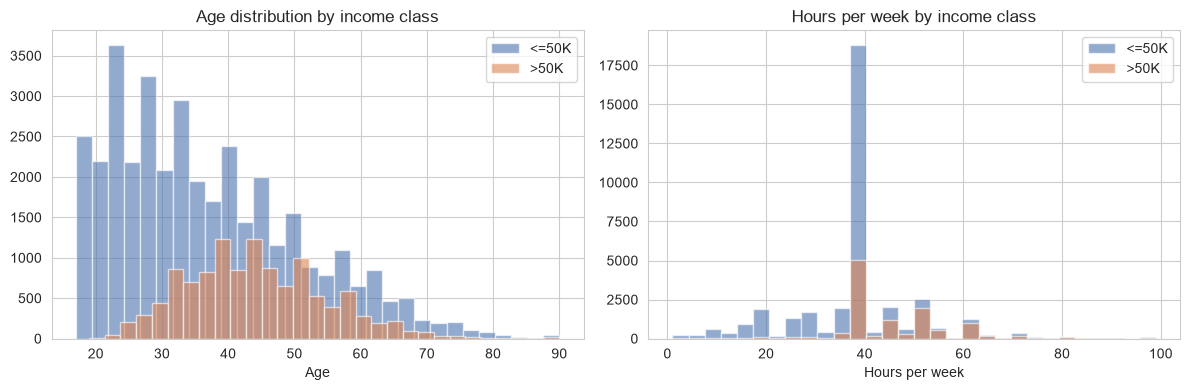

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df['target']==0, 'age'], bins=30, alpha=0.6, label='<=50K', color='#4C72B0')
axes[0].hist(df.loc[df['target']==1, 'age'], bins=30, alpha=0.6, label='>50K', color='#DD8452')
axes[0].set_title('Age distribution by income class')
axes[0].set_xlabel('Age')
axes[0].legend()

axes[1].hist(df.loc[df['target']==0, 'hours-per-week'], bins=30, alpha=0.6, label='<=50K', color='#4C72B0')
axes[1].hist(df.loc[df['target']==1, 'hours-per-week'], bins=30, alpha=0.6, label='>50K', color='#DD8452')
axes[1].set_title('Hours per week by income class')
axes[1].set_xlabel('Hours per week')
axes[1].legend()
plt.savefig("charts/age_hours_distribution.png", dpi=300, bbox_inches="tight")  
plt.tight_layout()
plt.show()

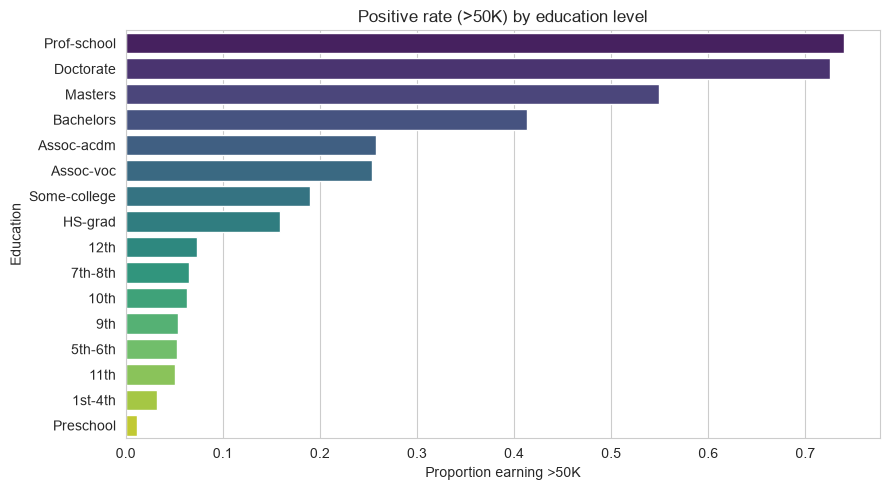

In [53]:
edu_order = df.groupby('education')['target'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=edu_order.values, y=edu_order.index, hue=edu_order.index, palette='viridis', legend=False)
plt.title('Positive rate (>50K) by education level')
plt.xlabel('Proportion earning >50K')
plt.ylabel('Education')
plt.savefig("charts/positive_rate_by_education.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

**Notable patterns from the EDA:**
- the positive class skews visibly older, most high earners cluster in the 35 to 55 age range, while low earners are concentrated in the 20s
- high earners work more hours per week on average, with a second bump right around 40 to 50 hours
- education is a strong signal, doctorate, professional school, and masters holders earn over 50K at a much higher rate than people with only some high school

These three patterns already hint that `age`, `hours-per-week`, and `education-num` will matter for modeling later this week.

**Additional EDA visualizations.** The three plots above are a good start, but the following charts reveal more structure in the data that will inform feature engineering decisions later this week: a correlation heatmap to check for redundant numeric features, box plots to see how spread differs by income class, income rates across demographic categories, a missing-value profile, and a per-occupation income ranking.

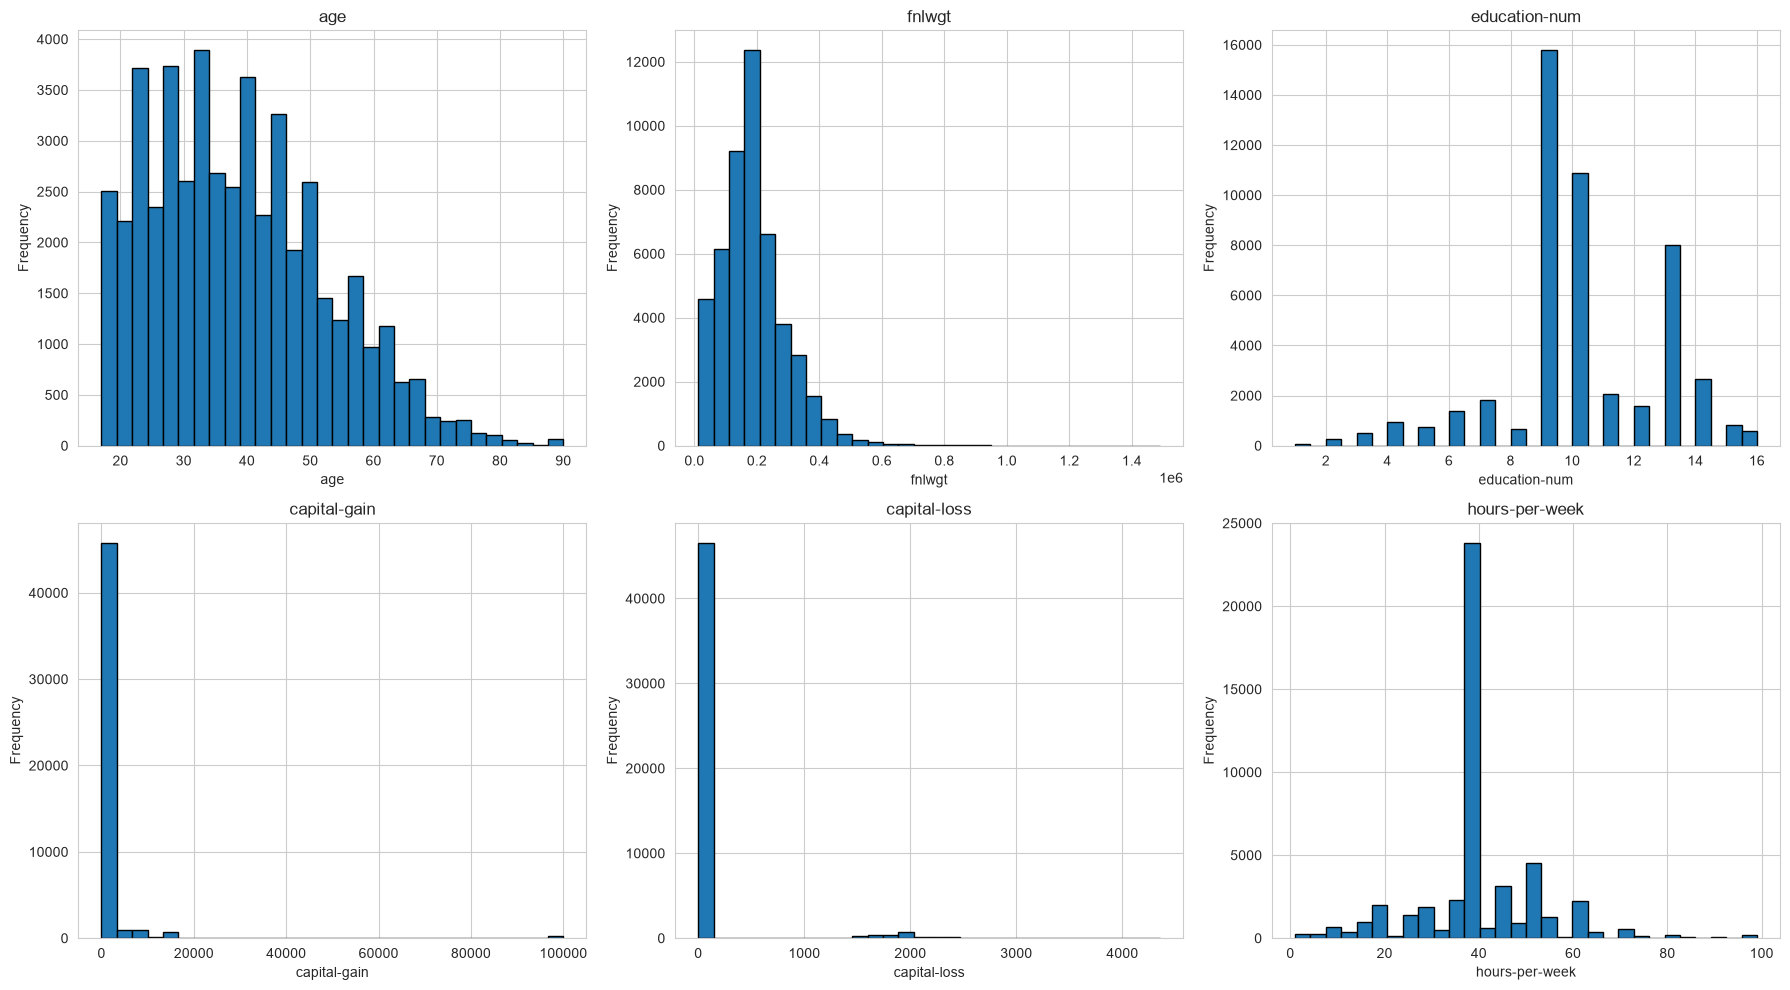

In [54]:
import os
import math
os.makedirs("charts", exist_ok=True)

# Numeric columns (exclude target)
numeric_cols = [col for col in df.select_dtypes(include=["number"]).columns if col != "target"]
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Remove any empty subplots
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig("charts/numeric_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

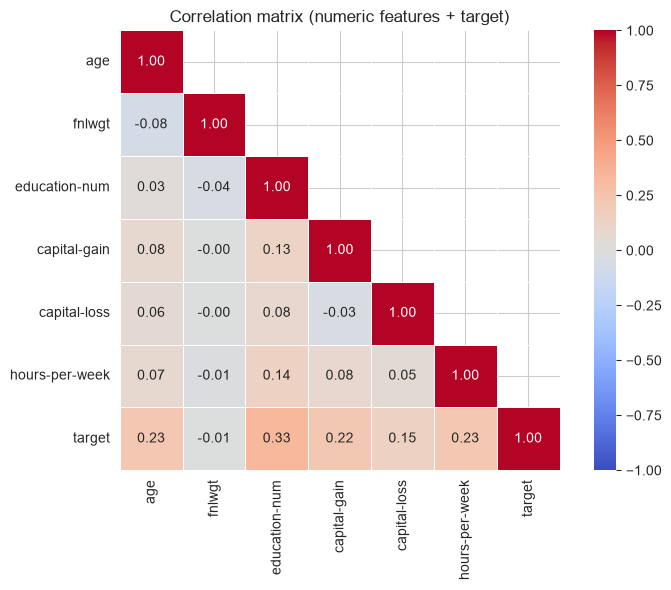

In [55]:
corr_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week", "target"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix (numeric features + target)")
plt.savefig("charts/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

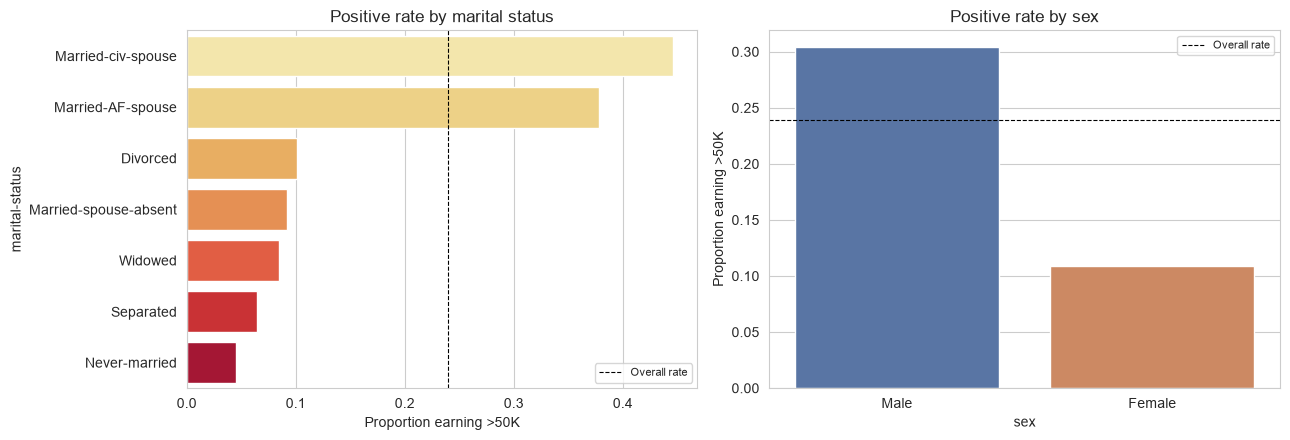

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Marital status
ms_order = df.groupby("marital-status")["target"].mean().sort_values(ascending=False)
sns.barplot(x=ms_order.values, y=ms_order.index, hue=ms_order.index, ax=axes[0],
            palette="YlOrRd", legend=False)
axes[0].set_title("Positive rate by marital status")
axes[0].set_xlabel("Proportion earning >50K")
axes[0].axvline(df["target"].mean(), color="black", ls="--", lw=0.8, label="Overall rate")
axes[0].legend(fontsize=8)

# Sex
sx = df.groupby("sex")["target"].mean().sort_values(ascending=False)
sns.barplot(x=sx.index, y=sx.values, hue=sx.index, ax=axes[1], palette=["#4C72B0", "#DD8452"], legend=False)
axes[1].set_title("Positive rate by sex")
axes[1].set_ylabel("Proportion earning >50K")
axes[1].axhline(df["target"].mean(), color="black", ls="--", lw=0.8, label="Overall rate")
axes[1].legend(fontsize=8)
plt.savefig("charts/positive_rate_by_marital_status_sex.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

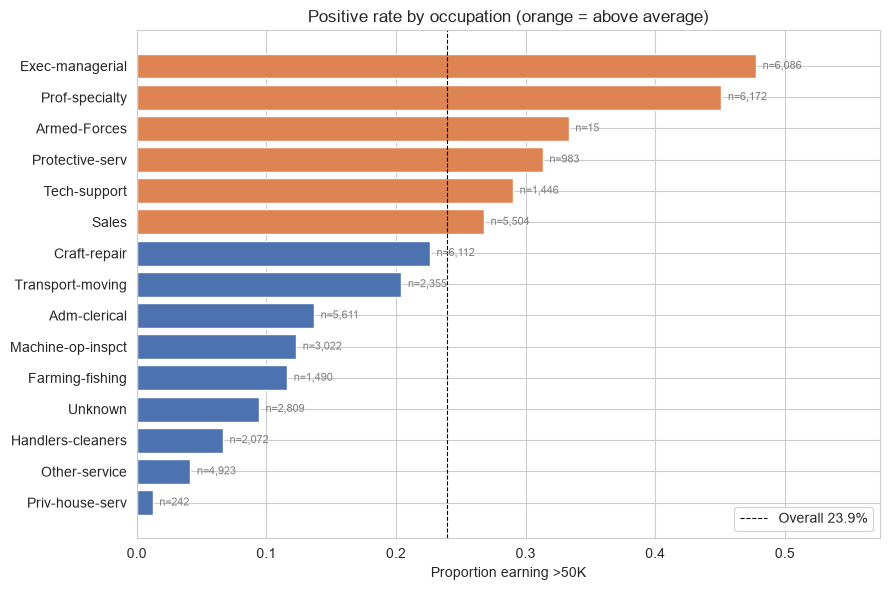

In [57]:
occ_order = df.groupby("occupation")["target"].mean().sort_values(ascending=True)
occ_counts = df.groupby("occupation")["target"].count()

plt.figure(figsize=(9, 6))
colors = ["#DD8452" if v > df["target"].mean() else "#4C72B0" for v in occ_order.values]
plt.barh(occ_order.index, occ_order.values, color=colors, edgecolor="white")
plt.axvline(df["target"].mean(), color="black", ls="--", lw=0.8, label="Overall 23.9%")
plt.title("Positive rate by occupation (orange = above average)")
plt.xlabel("Proportion earning >50K")
plt.legend()
# add sample size labels
for i, (occ, rate) in enumerate(occ_order.items()):
    plt.text(rate + 0.005, i, f"n={occ_counts[occ]:,}", va="center", fontsize=8, color="gray")
plt.xlim(0, occ_order.max() * 1.2)
plt.savefig("charts/positive_rate_by_occupation.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Task 3: Create Reproducible Splits

**Why a hold-out test set matters:** if we tune our model choices and hyperparameters while looking at test set performance, we are indirectly fitting the model to the test set through our own decisions, even if the model itself never sees that data directly. The test score then stops being an honest estimate of how the model will do on genuinely new people, it becomes an optimistic number that reflects our tuning as much as the model's real skill. The fix is to lock away a hold-out set now, do all exploration and tuning on the rest of the data, and only touch the hold-out once, at the very end, to report a final number.

We use `stratify=df['target']` so the 24%/76% class balance is preserved in both the training data and the hold-out set, and a fixed `random_state` so this exact split can be reproduced on any machine, by anyone, at any time.

We also carve out a small dev set from the remaining 80%. The dev set is for fast iteration during the week (quick comparisons between models, feature ideas, etc.) without ever touching the hold-out test set.

In [58]:
feature_cols = [c for c in df.columns if c not in ['income', 'target']]

X = df[feature_cols]
y = df['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# dev set: ~10% of the total, taken out of the remaining 80%
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.125, stratify=y_train_full, random_state=RANDOM_STATE
)

print(f"Train:   {X_train.shape[0]} rows ({y_train.mean():.3f} positive rate)")
print(f"Dev:     {X_dev.shape[0]} rows ({y_dev.mean():.3f} positive rate)")
print(f"Hold-out test: {X_test.shape[0]} rows ({y_test.mean():.3f} positive rate)")

Train:   34188 rows (0.239 positive rate)
Dev:     4885 rows (0.239 positive rate)
Hold-out test: 9769 rows (0.239 positive rate)


The positive rate is close to 24% in all three splits, which confirms the stratification worked correctly. From this point forward in the notebook, the hold-out test set is only touched to report final baseline numbers below, and it will not be touched again until final model evaluation later in the week.

## Task 4: Implement Simple Baselines

**Baseline 1: majority-class predictor.** Always predicts the most frequent class, which here is `<=50K`. This baseline needs zero intelligence, it exists purely to set a floor. Any real model that cannot beat this is not worth deploying.

**Baseline 2: rule-based classifier.** We tested three candidate rules on the full dataset before picking one:


In [59]:
# Compare candidate rules on the FULL dataset (before split)
rules = {
    "capital-gain > 0": (df["capital-gain"] > 0).astype(int),
    "education-num >= 13": (df["education-num"] >= 13).astype(int),
    "edu>=13 OR cap-gain>0": ((df["education-num"] >= 13) | (df["capital-gain"] > 0)).astype(int),
}

rule_comparison = pd.DataFrame([
    {
        "Rule": name,
        "Precision": precision_score(df["target"], pred, zero_division=0),
        "Recall": recall_score(df["target"], pred, zero_division=0),
        "Flags %": pred.mean().round(3),
    }
    for name, pred in rules.items()
]).round(2)

rule_comparison

,Rule,Precision,Recall,Flags %
0,capital-gain > 0,0.62,0.21,0.08
1,education-num >= 13,0.48,0.50,0.25
2,edu>=13 OR cap-gain>0,0.48,0.59,0.30


`capital-gain > 0` is the most precise single rule but it only fires on 8% of rows, making it too narrow to serve as a meaningful baseline. `education-num >= 13` alone covers 25% of people with decent precision. The combined rule (`education-num >= 13 OR capital-gain > 0`) adds the high-precision capital-gain group on top, which pushes recall up noticeably while keeping precision almost the same as education alone. Since it dominates the education-only rule on both precision and recall, we use the **combined rule** as our rule-based baseline.

Note: these numbers are computed on the full dataset before the train/test split, purely to pick which rule to use. The actual baseline evaluation against the hold-out test set is below, where the rule has not seen any test data.

In [60]:
# Baseline 1: majority class
majority_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
majority_clf.fit(X_train, y_train)
majority_pred = majority_clf.predict(X_test)
majority_score = np.zeros(len(X_test))

# Baseline 2: combined rule (education-num >= 13 OR capital-gain > 0)
rule_pred = ((X_test["education-num"] >= 13) | (X_test["capital-gain"] > 0)).astype(int).to_numpy()
rule_score = rule_pred.astype(float)

def evaluate(y_true, y_pred, y_score, name):
    constant_score = len(set(y_score)) <= 1
    return {
        "baseline": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": np.nan if constant_score else roc_auc_score(y_true, y_score),
        "pr_auc": np.nan if constant_score else average_precision_score(y_true, y_score),
    }

results = pd.DataFrame([
    evaluate(y_test, majority_pred, majority_score, "Majority class"),
    evaluate(y_test, rule_pred, rule_score, "Rule: edu>=13 OR cap-gain>0"),
]).set_index("baseline").round(3)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
baseline,,,,,,
Majority class,0.761,0.000,0.000,0.000,NaN,NaN
Rule: edu>=13 OR cap-gain>0,0.745,0.475,0.603,0.531,0.697,0.381


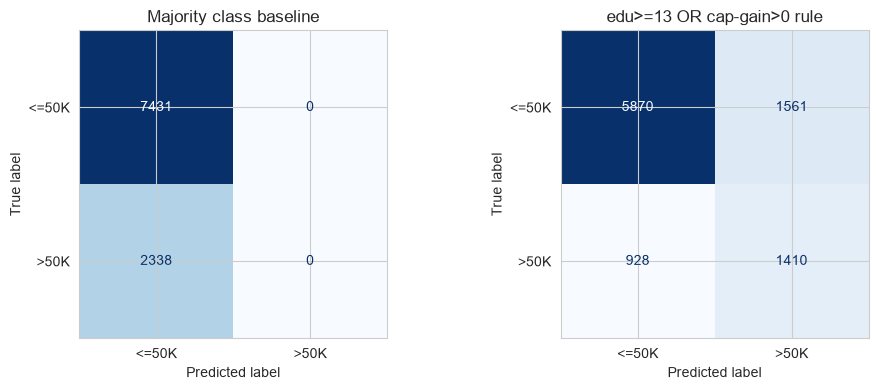

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm1 = confusion_matrix(y_test, majority_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm1, display_labels=['<=50K', '>50K']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Majority class baseline')

cm2 = confusion_matrix(y_test, rule_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm2, display_labels=['<=50K', '>50K']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('edu>=13 OR cap-gain>0 rule')
plt.savefig("charts/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

**ROC and Precision-Recall curves.** The confusion matrices give a snapshot at one threshold, but these curves show model performance across every possible threshold. The diagonal dashed line on the ROC plot is what a random guesser would achieve. The further our curve bulges toward the top-left, the better the model ranks positive instances above negative ones. The PR curve is often more informative on imbalanced datasets like this one (76% negative class), because the baseline there is not 0.5 but the proportion of positives (about 24%), shown as the horizontal dashed line.

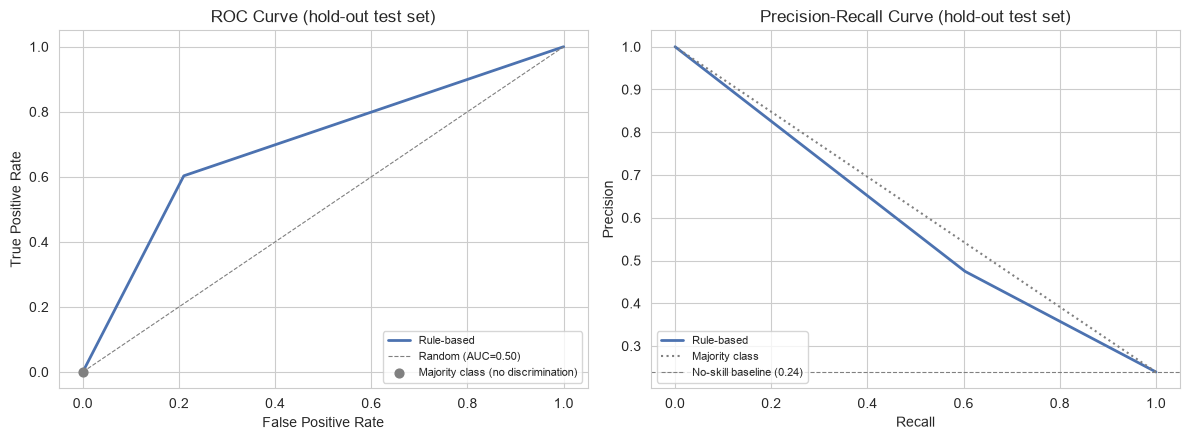

In [62]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# For the majority-class baseline, use a constant score equal to the training
# positive rate so that PR curve has a meaningful horizontal reference line.
maj_score_for_pr = np.full(len(y_test), y_train.mean())

# -- ROC Curve --
fpr_rule, tpr_rule, _ = roc_curve(y_test, rule_score)

axes[0].plot(fpr_rule, tpr_rule, label="Rule-based", color="#4C72B0", lw=2)
axes[0].plot([0, 1], [0, 1], ls="--", color="gray", lw=0.8, label="Random (AUC=0.50)")
axes[0].scatter([0], [0], color="gray", s=40, zorder=5, label="Majority class (no discrimination)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (hold-out test set)")
axes[0].legend(loc="lower right", fontsize=8)

# -- Precision-Recall Curve --
prec_rule, rec_rule, _ = precision_recall_curve(y_test, rule_score)
prec_maj, rec_maj, _ = precision_recall_curve(y_test, maj_score_for_pr)

axes[1].plot(rec_rule, prec_rule, label="Rule-based", color="#4C72B0", lw=2)
axes[1].plot(rec_maj, prec_maj, label="Majority class", ls=":", color="gray")
axes[1].axhline(y_test.mean(), ls="--", color="gray", lw=0.8, label=f"No-skill baseline ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (hold-out test set)")
axes[1].legend(loc="lower left", fontsize=8)
plt.savefig("charts/roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

**Interpretation.** The majority-class baseline gets high accuracy but scores zero on precision, recall, and F1, because it never predicts a single positive. It is not actually useful for the business goal even though the accuracy number looks fine on paper. This is exactly why accuracy alone is a misleading metric for an imbalanced problem like this one. The combined rule baseline is clearly the stronger of the two on every metric that matters (precision, F1, ROC AUC, PR AUC). It wins because it combines two independent signals, education level and investment income, to catch more high earners while keeping precision solid.

For a real model to be considered useful this week, it needs to meaningfully beat the combined rule baseline's precision shown above, not just beat the majority-class floor. A reasonable target is at least a few points of precision above the rule baseline, ideally while also improving recall rather than sacrificing it entirely.

## Task 5: Initial Error Analysis and Next Steps

We look at the rule-based baseline's mistakes, since the majority-class baseline's errors are trivial (every single positive person is a false negative, there is nothing more to learn from that).

In [63]:
test_df = X_test.copy()
test_df['actual'] = y_test.values
test_df['predicted'] = rule_pred

false_positives = test_df[(test_df['actual'] == 0) & (test_df['predicted'] == 1)]
false_negatives = test_df[(test_df['actual'] == 1) & (test_df['predicted'] == 0)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

cols_to_show = ['age', 'education', 'occupation', 'hours-per-week', 'marital-status', 'capital-gain']
false_positives[cols_to_show].sample(10, random_state=RANDOM_STATE)

False positives: 1561
False negatives: 928


,age,education,occupation,hours-per-week,marital-status,capital-gain
23717,41,Bachelors,Prof-specialty,40,Never-married,0
22892,24,Bachelors,Exec-managerial,40,Never-married,0
42409,37,Bachelors,Transport-moving,50,Separated,0
22958,18,11th,Other-service,4,Never-married,594
1438,41,Masters,Prof-specialty,35,Divorced,0
25256,58,Bachelors,Exec-managerial,40,Widowed,0
35392,27,Masters,Prof-specialty,45,Never-married,0
27647,35,Bachelors,Sales,40,Never-married,0
20635,46,Bachelors,Prof-specialty,40,Divorced,0
33001,32,HS-grad,Adm-clerical,40,Married-civ-spouse,2580


In [64]:
false_negatives[cols_to_show].sample(10, random_state=RANDOM_STATE)

,age,education,occupation,hours-per-week,marital-status,capital-gain
45369,67,11th,Other-service,9,Married-civ-spouse,0
15296,54,Assoc-acdm,Sales,50,Married-civ-spouse,0
17404,38,10th,Sales,40,Married-civ-spouse,0
28453,38,Assoc-voc,Tech-support,36,Married-civ-spouse,0
44586,51,Some-college,Craft-repair,48,Married-civ-spouse,0
18149,36,HS-grad,Craft-repair,60,Married-civ-spouse,0
44641,25,Assoc-voc,Craft-repair,40,Married-civ-spouse,0
30215,50,Some-college,Exec-managerial,40,Married-civ-spouse,0
40422,48,HS-grad,Craft-repair,40,Married-civ-spouse,0
1395,42,10th,Transport-moving,40,Never-married,0


In [65]:
print("False positives (rule said >50K, actually <=50K):")
print(false_positives[['age', 'hours-per-week']].describe().round(1).loc[['mean', '50%']])
print()
print("False negatives (rule said <=50K, actually >50K):")
print(false_negatives[['age', 'hours-per-week']].describe().round(1).loc[['mean', '50%']])
print()
print("False negative marital status breakdown:")
print(false_negatives['marital-status'].value_counts(normalize=True).round(3).head(4))

False positives (rule said >50K, actually <=50K):
       age  hours-per-week
mean  38.7            40.0
50%   36.0            40.0

False negatives (rule said <=50K, actually >50K):
       age  hours-per-week
mean  44.0            44.5
50%   43.0            40.0

False negative marital status breakdown:
marital-status
Married-civ-spouse    0.915
Divorced              0.038
Never-married         0.027
Widowed               0.010
Name: proportion, dtype: float64


**Error profile visualization.** The tables above are useful for spot-checking individual rows, but plots make it much easier to see the systematic differences between false positives and false negatives. The histograms below compare the age and education-num distributions of the two error types against the overall test-set mean.

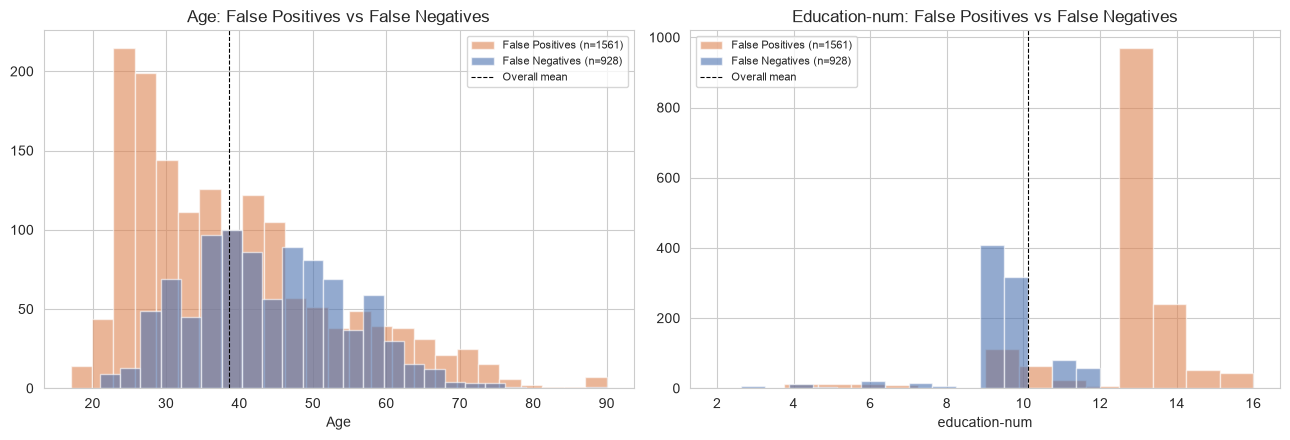

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Age
axes[0].hist(false_positives["age"], bins=25, alpha=0.6, color="#DD8452", label=f"False Positives (n={len(false_positives)})")
axes[0].hist(false_negatives["age"], bins=25, alpha=0.6, color="#4C72B0", label=f"False Negatives (n={len(false_negatives)})")
axes[0].axvline(test_df["age"].mean(), color="black", ls="--", lw=0.8, label="Overall mean")
axes[0].set_title("Age: False Positives vs False Negatives")
axes[0].set_xlabel("Age")
axes[0].legend(fontsize=8)

# Education-num
axes[1].hist(false_positives["education-num"], bins=16, alpha=0.6, color="#DD8452", label=f"False Positives (n={len(false_positives)})")
axes[1].hist(false_negatives["education-num"], bins=16, alpha=0.6, color="#4C72B0", label=f"False Negatives (n={len(false_negatives)})")
axes[1].axvline(test_df["education-num"].mean(), color="black", ls="--", lw=0.8, label="Overall mean")
axes[1].set_title("Education-num: False Positives vs False Negatives")
axes[1].set_xlabel("education-num")
axes[1].legend(fontsize=8)
plt.savefig("charts/false_pos_neg_histograms.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

**Patterns spotted in the sample:**
- most false positives are degree holders in lower paying occupations (adm-clerical, sales, some service roles) or younger graduates still early in their career. Having a degree does not guarantee income yet, the rule cannot see occupation or experience at all
- a lot of false negatives are people without a Bachelors who nonetheless work long hours and are older, this looks like self-employed or trade occupations where income comes from experience and hustle rather than a formal degree
- married individuals show up disproportionately among false negatives, `marital-status` looks like it carries real signal that a single education-only rule is completely blind to

**Data and feature issues to fix before modeling tomorrow:**
1. `workclass`, `occupation`, and `native-country` all have missing values (from the original `?` entries), need a strategy or model-based imputation, dropping those rows would lose real signal
2. `education` and `education-num` are redundant, `education-num` is just the ordinal encoding of `education`, keep one and drop the other to avoid duplicate information
3. `capital-gain` and `capital-loss` are extremely skewed, the vast majority of values are exactly zero with a long tail of large values, worth log-transforming or bucketing rather than feeding in raw
4. `fnlwgt` is a census sampling weight, not a real attribute of the person, it should probably be dropped entirely since it has no business meaning for predicting an individual's income
5. `native-country` is high cardinality with the US dominating the vast majority of rows, needs grouping into fewer buckets (for example US vs not US) rather than one-hot encoding every country
6. categorical features (`workclass`, `occupation`, `marital-status`, `relationship`, `race`, `sex`, `native-country`) all need proper encoding before any model beyond a simple rule can use them

**Primary metric for the rest of the week: Precision.**   
The majority-class baseline scores 0.0 on precision, since it never predicts a positive at all. The combined rule baseline (education-num >= 13 OR capital-gain > 0) reaches the precision shown in the results table above. We chose this over the narrower capital-gain > 0 rule, which has higher precision (0.62) but only flags 8% of people, too small a pool to build a real outreach campaign around. The combined rule accepts a lower precision in exchange for a usable flag rate and meaningfully better recall, while staying close to what education alone would have given us on precision. Since the business goal is to avoid wasting outreach budget on people who are not actually high earners, precision is still the single number we track to compare every model this week. We will monitor recall to make sure we are not being so conservative that the campaign has nobody to contact, but when two models have similar precision we break ties with recall. Anything we build tomorrow needs to clear the combined rule's precision by a real margin, not just barely edge past it, before it is worth taking further.